# Modello ARIMA applicato a serie temporale di dati rilevati da sensori


## Setup


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from util import (
    load_building_df,
    plot_dataframe,
    show_overview_for_value,
)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%reload_ext autoreload
%autoreload 2

Il notebook usa come esempio i dati dei consumi energetici dell'edificio 14.


(0.0, 637.875)

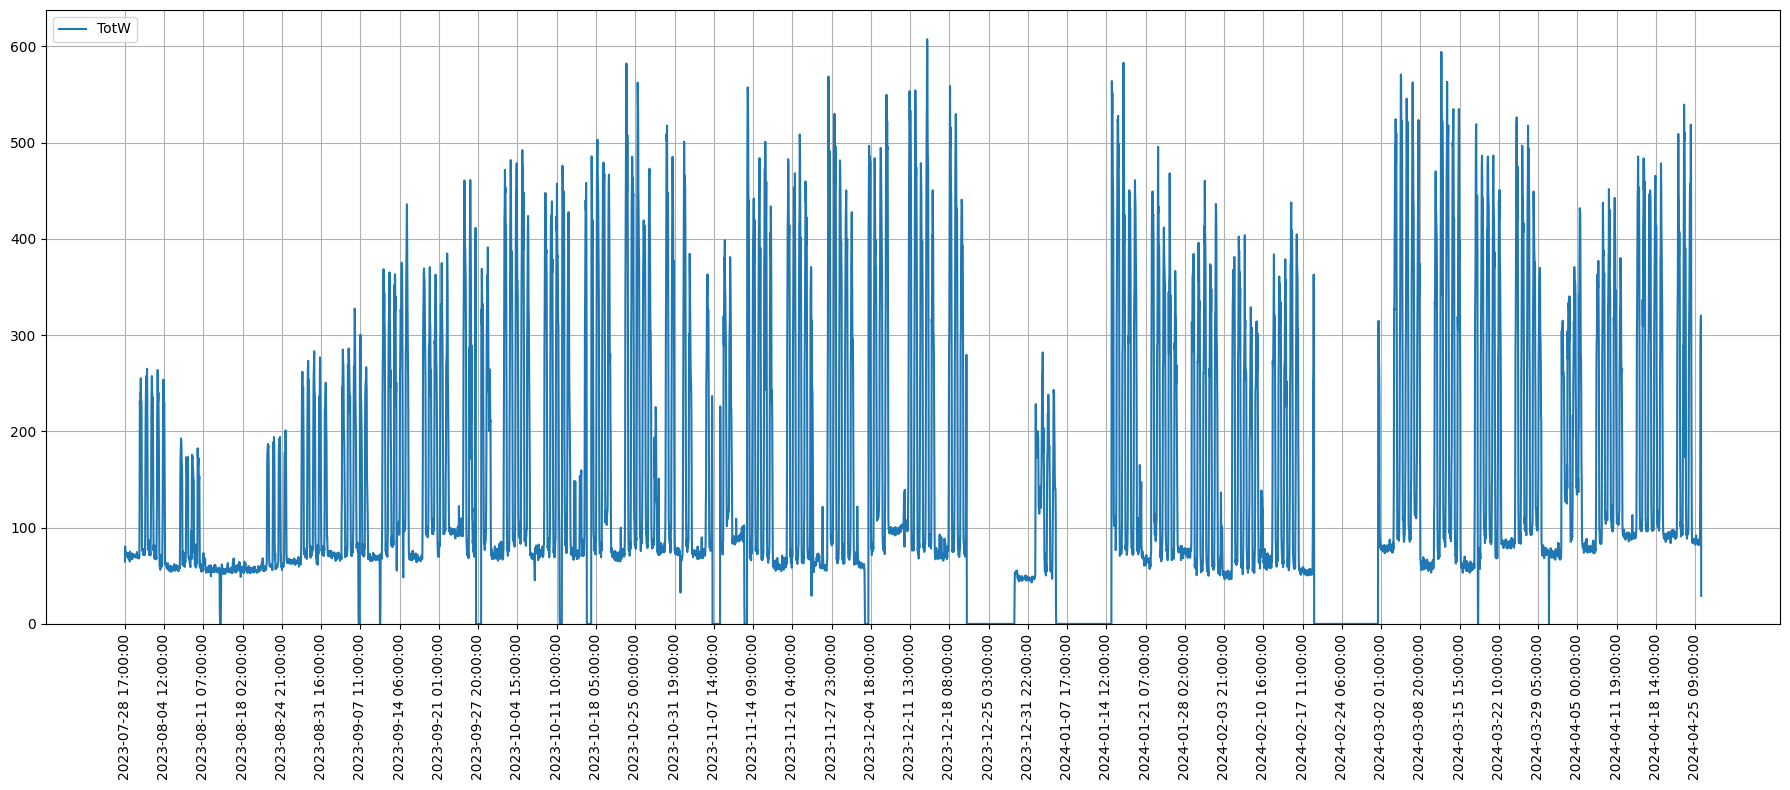

In [2]:
df = load_building_df(
    "TotW",
    "ED14_20240426.csv",
    "PM5320",
    "ARCH_FM",
    resample="h",
)


plot_dataframe(df, ["TotW"])
plt.ylim(0)

In [3]:
df

,TotW,hour,dayofweek,week
datetime,,,,
2023-07-28 17:00:00,64.77,17,4,29
2023-07-28 18:00:00,80.33,18,4,29
2023-07-28 19:00:00,70.98,19,4,29
2023-07-28 20:00:00,73.86,20,4,29
2023-07-28 21:00:00,74.25,21,4,29
...,...,...,...,...
2024-04-26 06:00:00,146.43,6,4,16
2024-04-26 07:00:00,286.99,7,4,16
2024-04-26 08:00:00,310.51,8,4,16


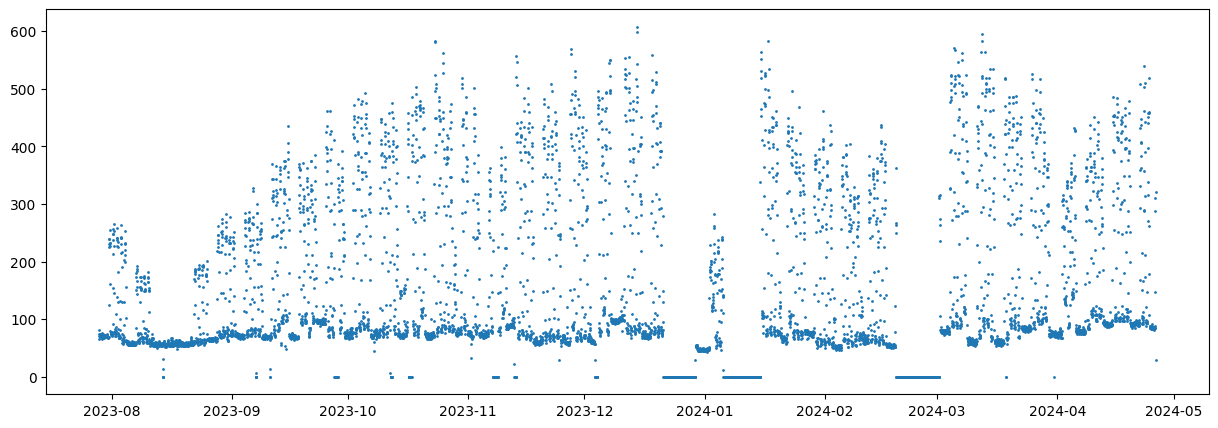

In [4]:
plt.figure(figsize=(15, 5))
plt.scatter(df.index, df["TotW"], s=1)

In [5]:
show_overview_for_value(df, "TotW")

## Studio della stationarity

Una serie temporale è detta **stazionaria** se le sue proprietà statistiche (come media e varianza) rimangono costanti nel tempo. Il modello ARIMA può essere utilizzato sia per serie stazionarie che non, ma nel secondo caso sarà necessario determinare il parametro `d` del modello, ossia il grado di differencing da applicare alla serie temporale.

È possibile fare uso di diverse tecniche per determinare se una serie temporale è stazionaria o meno, mostrati nei paragrafi successivi:

- studio di media e varianza nel tempo;
- Test ADF;
- Test KPSS.


### Via grafo della media e della varianza

Un'iniziale ispezione dei grafi di media e varianza dei consumi energetici (TotW), generati usando rolling window di diverse dimensioni, mostra che media e varianza cambiano molto frequentemente: questo dà un'indicazione di non-stazionarità.


<Axes: >

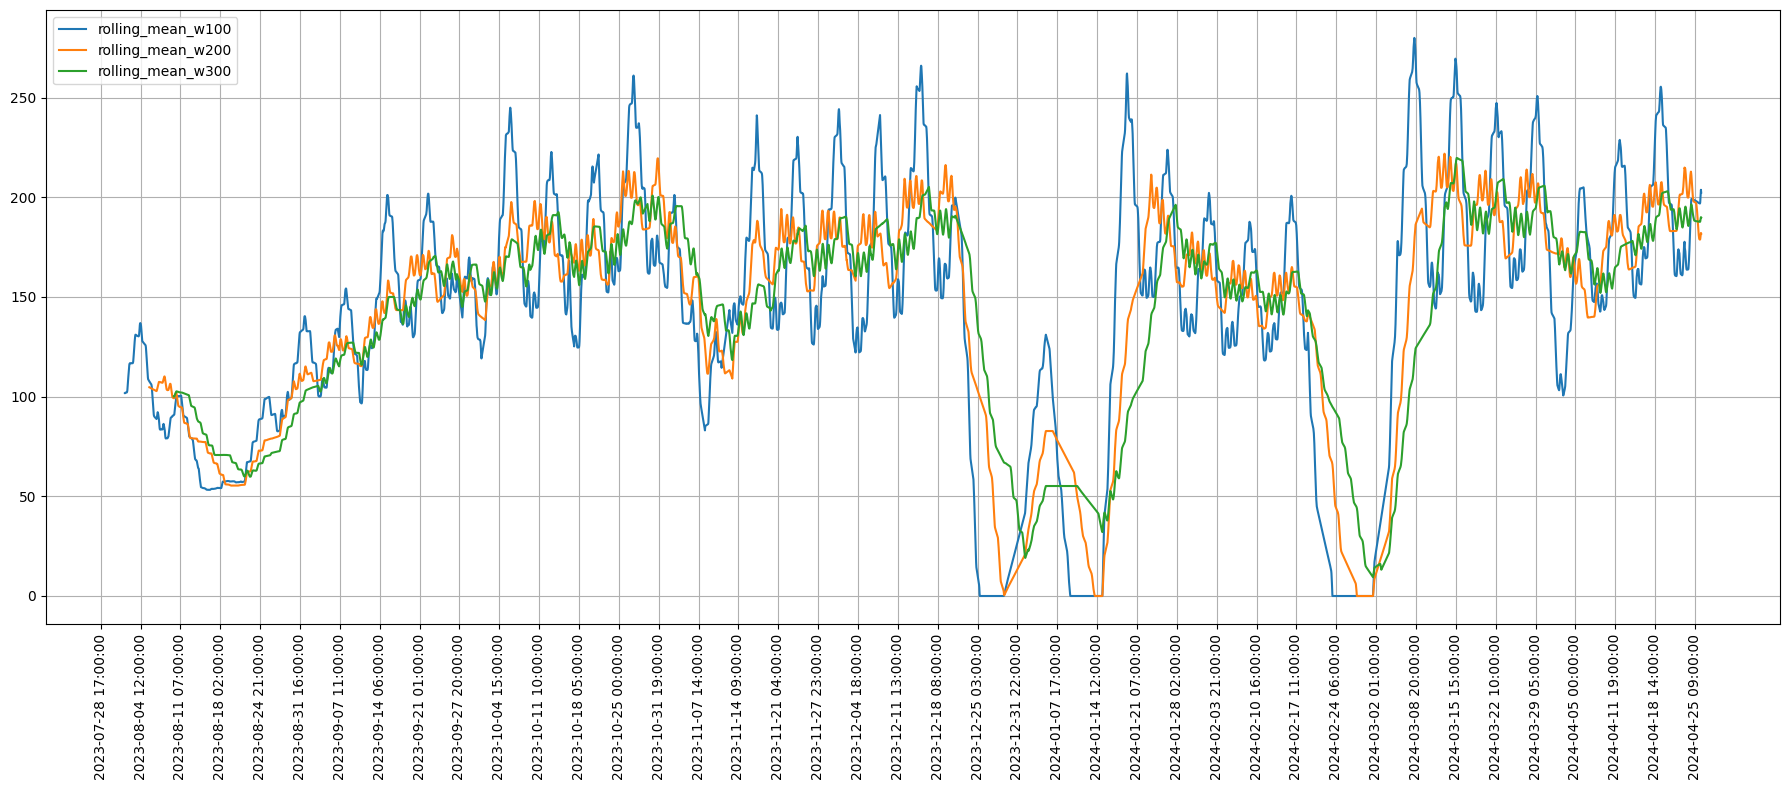

In [6]:
df["rolling_mean_w100"] = df["TotW"].rolling(window=100).mean()
df["rolling_mean_w200"] = df["TotW"].rolling(window=200).mean()
df["rolling_mean_w300"] = df["TotW"].rolling(window=300).mean()

plot_dataframe(
    df,
    [
        "rolling_mean_w100",
        "rolling_mean_w200",
        "rolling_mean_w300",
    ],
)

<Axes: >

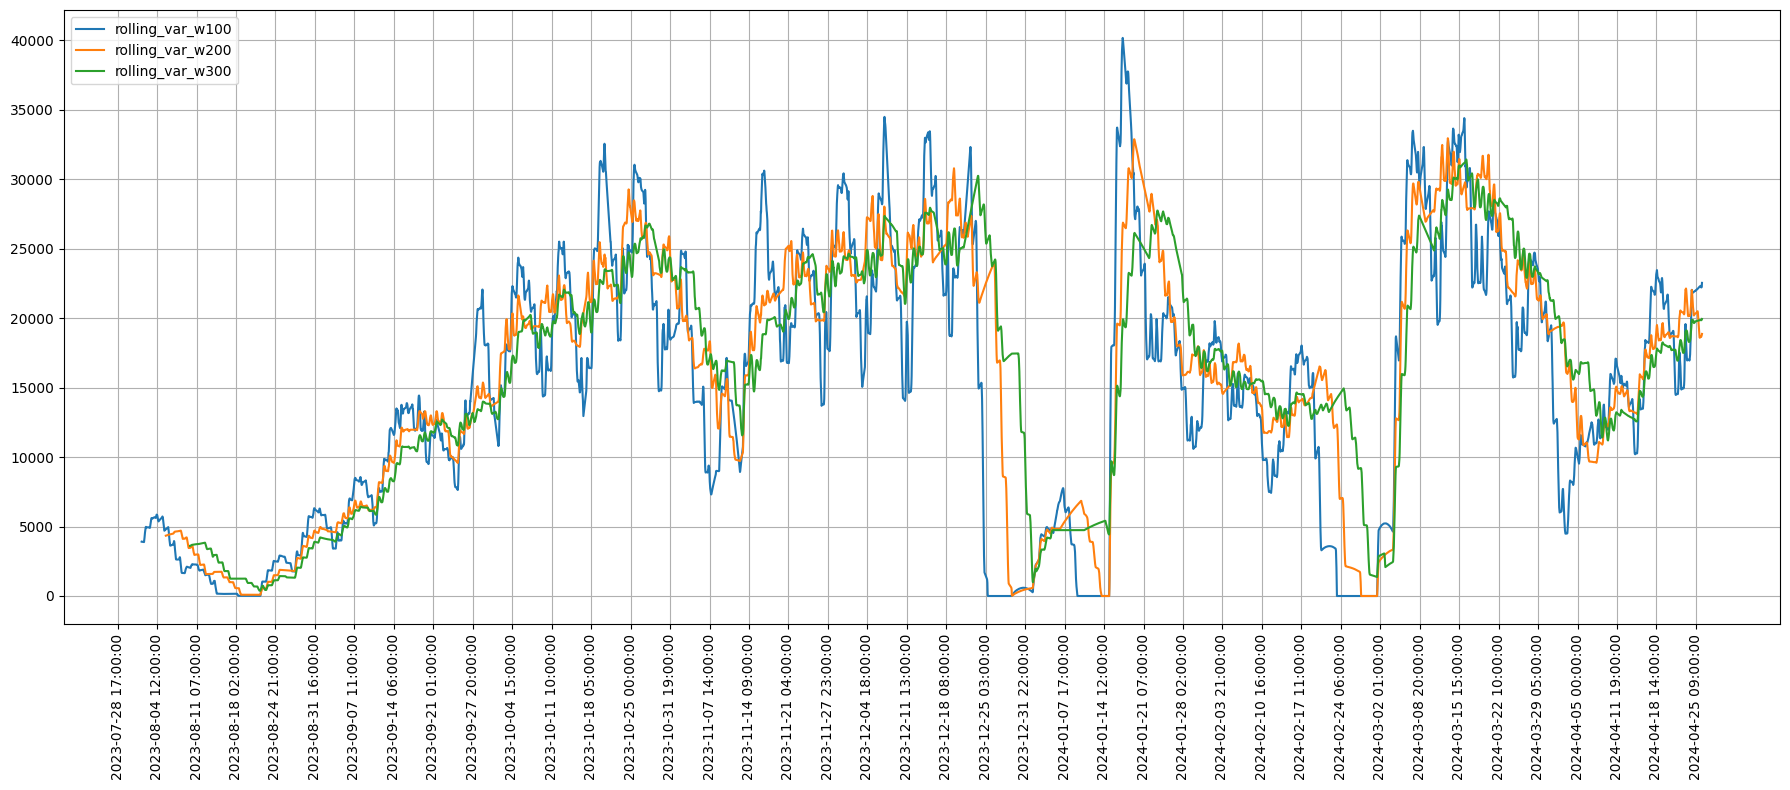

In [7]:
df["rolling_var_w300"] = df["TotW"].rolling(window=300).var()
df["rolling_var_w200"] = df["TotW"].rolling(window=200).var()
df["rolling_var_w100"] = df["TotW"].rolling(window=100).var()

plot_dataframe(
    df,
    [
        "rolling_var_w100",
        "rolling_var_w200",
        "rolling_var_w300",
    ],
)

### Via test Augmented Dickey-Fuller

Il test Augmented Dickey-Fuller considera due ipotesi:

- Ipotesi nulla $H_0$: la serie temporale non è stazionaria;
- Ipotesi alternative $H_1$: la serie temporale è stazionaria.

Per rifiutare l'ipotesi nulla, si setta una soglia (tipicamente dello 0.05): se il p-value restituito dal test ADF è inferiore a questa soglia, l'ipotesi nulla è rifiutata, indicando che plausibilmente la serie temporale è stazionaria.


In [8]:
from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(df["TotW"])
adf_stat = adf_res[0]
adf_pvalue = adf_res[1]

print(f"ADF Statistic: {adf_stat}")
print(f"p-value:       {adf_pvalue}")

ADF Statistic: -8.379012436352996
p-value:       2.539873829361464e-13


Il p-value è molto inferiore alla soglia dello 0.05, quindi l'ipotesi nulla è rifiutata e la serie è stazionaria secondo questo test.


### Via test KPSS

Il test KPSS considera due ipotesi, opposte a quelle del test ADF:

- Ipotesi nulla $H_0$: la serie temporale _è stazionaria_;
- Ipotesi alternativa $H_1$: la serie temporale è non-stazionaria.

Per rifiutare l'ipotesi nulla si procede come per il test ADF: si setta una soglia (0.05), che sarà confrontata col p-value.


In [9]:
from statsmodels.tsa.stattools import kpss

kpss_res = kpss(df["TotW"])
kpss_stat = kpss_res[0]
kpss_pvalue = kpss_res[1]

print(f"KPSS Statistic: {kpss_stat}")
print(f"p-value:       {kpss_pvalue}")

KPSS Statistic: 0.48174218030653315
p-value:       0.04577878821924929


### Risultato

In sintesi, per il dataset inerente all'edificio 14:

- un'ispezione grafica rivela non-stazionarità;
- i risultati del test ADF indicano stazionarità;
- i risultati del test KPSS indicano non-stazionarità.

I risultati sono contrastanti: i grafici di media e varianza mostrano alta variabilità (e quindi non-stazionarità), mentre il test ADF e il test KPSS mostrano risultati opposti.


## Differencing


### Ordine del termine di differenziazione (d)

Il termine di differenziazione va identificato allo scopo di rimuovere la non-stazionarità da una serie temporale. Alla serie in questione verranno infatti sottratti i `d` lag precedenti allo scopo di ridurre la variazione di media e varianza nel plot.

In questo esempio, identifico il parametro in questione tramite un'ispezione visiva: decido che differenziare usando i primi 2 lag riduce sufficientemente la non-stazionarità.


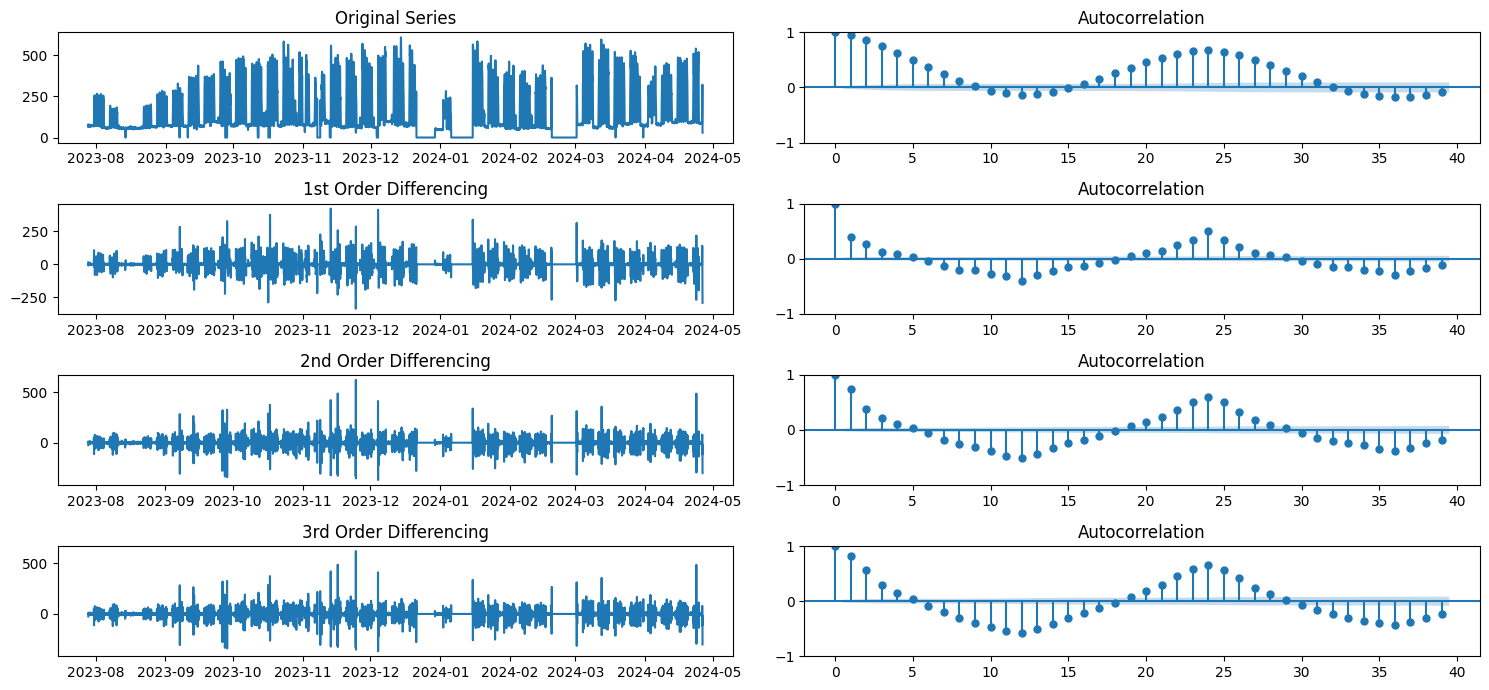

In [10]:
# Original Series
fig, axes = plt.subplots(4, 2, figsize=(15, 7))
axes[0, 0].plot(df["TotW"])
axes[0, 0].set_title("Original Series")
plot_acf(df["TotW"], ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df["TotW"].diff())
axes[1, 0].set_title("1st Order Differencing")
plot_acf(df["TotW"].diff(periods=1).dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df["TotW"].diff().diff())
axes[2, 0].set_title("2nd Order Differencing")
plot_acf(df["TotW"].diff(periods=2).dropna(), ax=axes[2, 1])


axes[3, 0].plot(df["TotW"].diff().diff())
axes[3, 0].set_title("3rd Order Differencing")
plot_acf(df["TotW"].diff(periods=3).dropna(), ax=axes[3, 1])

plt.tight_layout()
plt.show()

### Ordine del termine AR (p)

Il termine AR può essere identificato ispezionando il grafico della funzione PACF e selezionando il lag con la correlazione più significativa (in questo caso, il primo, per cui: `p = 1`).


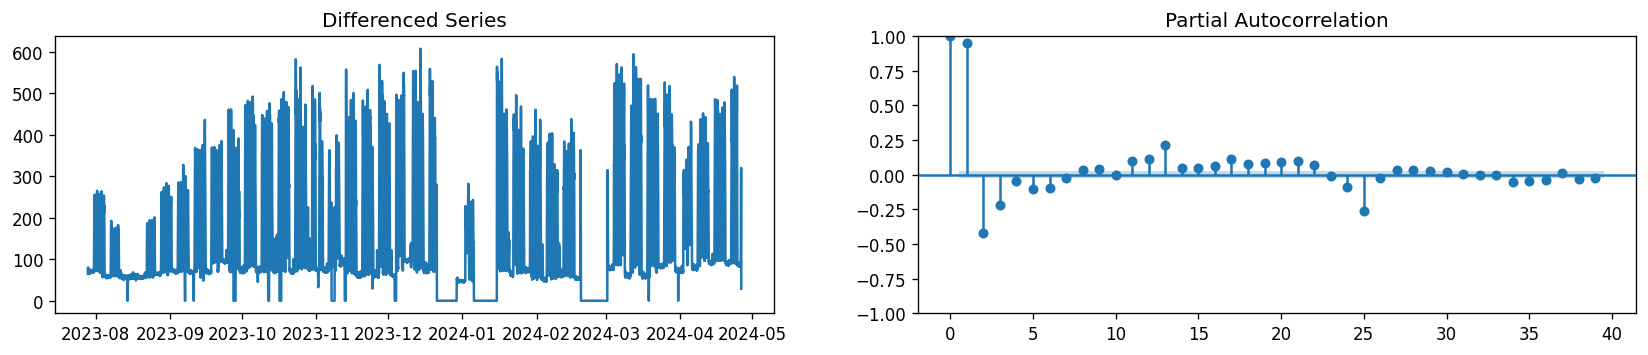

In [11]:
# PACF plot of 1st differenced series
plt.rcParams.update({"figure.figsize": (17, 3), "figure.dpi": 120})

fig, axes = plt.subplots(1, 2)

axes[0].plot(df["TotW"])
axes[0].set_title("Differenced Series")

plot_pacf(df["TotW"], ax=axes[1])

plt.show()

### Ordine del termine MA (q)


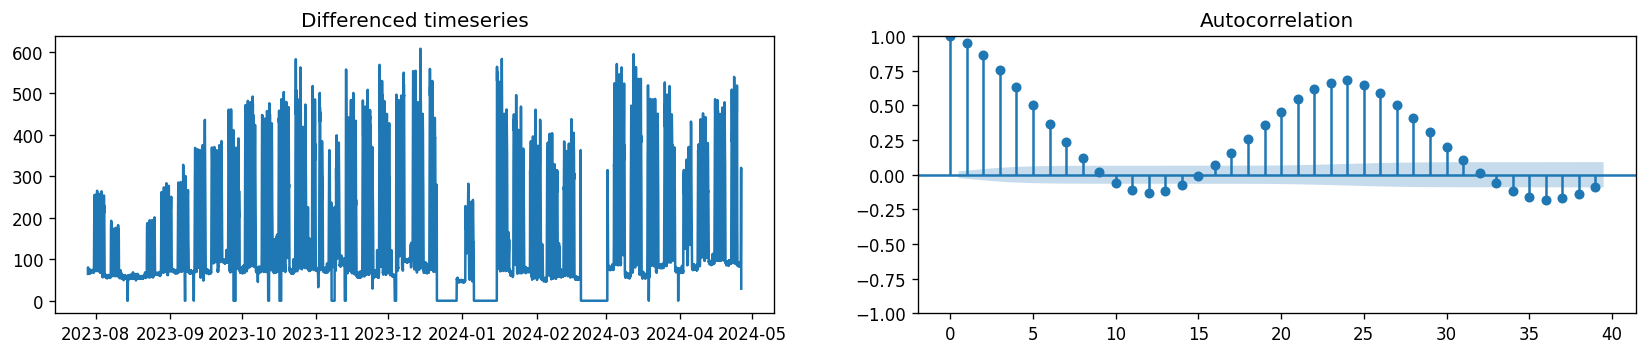

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({"figure.figsize": (17, 3), "figure.dpi": 120})

fig, axes = plt.subplots(1, 2)

axes[0].plot(df["TotW"])
axes[0].set_title("Differenced timeseries")
axes[1].set(ylim=(0, 1.2))

plot_acf(df["TotW"], ax=axes[1])

plt.show()

## Rimozione della seasonality


### De-trending

Il de-trending consiste nell'atto di rimuovere il trend da una timeseries.

Ho provato due strategie per raggiungere questo obiettivo:

- calcolare la rolling average della serie, e sottrarla alla serie originale;
- utilizzare il metodo `seasonal_decompose` della libreria `statsmodels.tsa.seasonal` e sottrarre il trend individuato


In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["TotW"], model="additive", period=30)
df["TotW_deseasonalized"] = df["TotW"] - result.seasonal

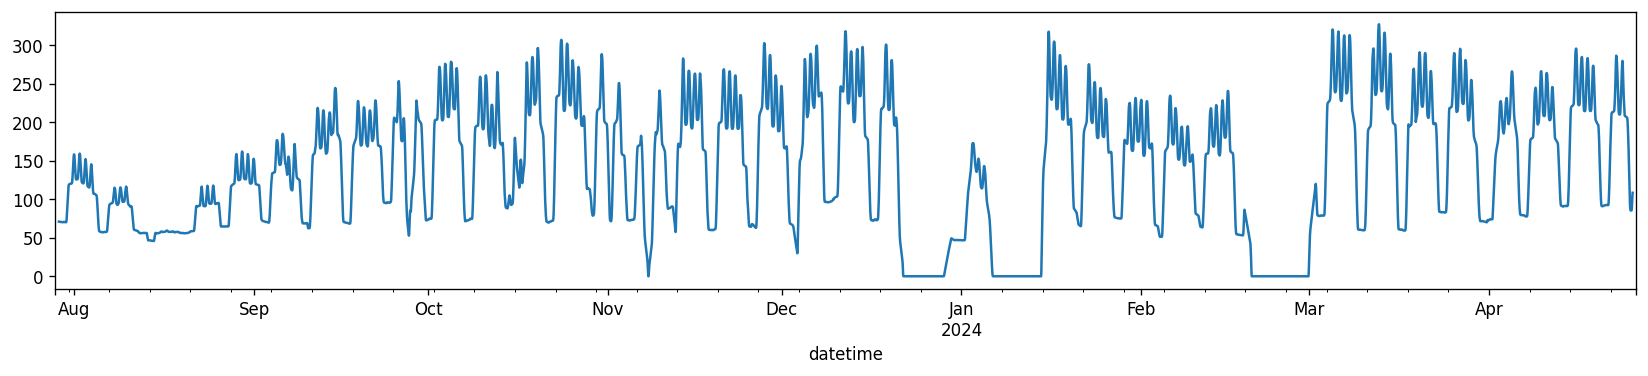

In [14]:
fig = result.trend.plot()

<Axes: xlabel='datetime'>

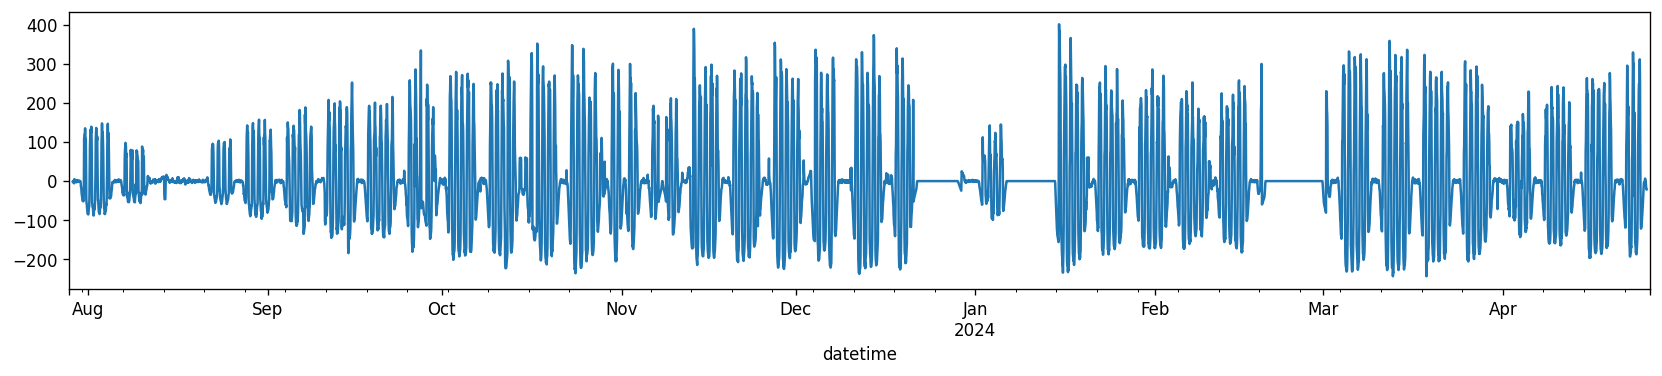

In [15]:
df["detrended"] = df["TotW"] - result.trend
df["detrended"].plot()

### Grafico post-detrending


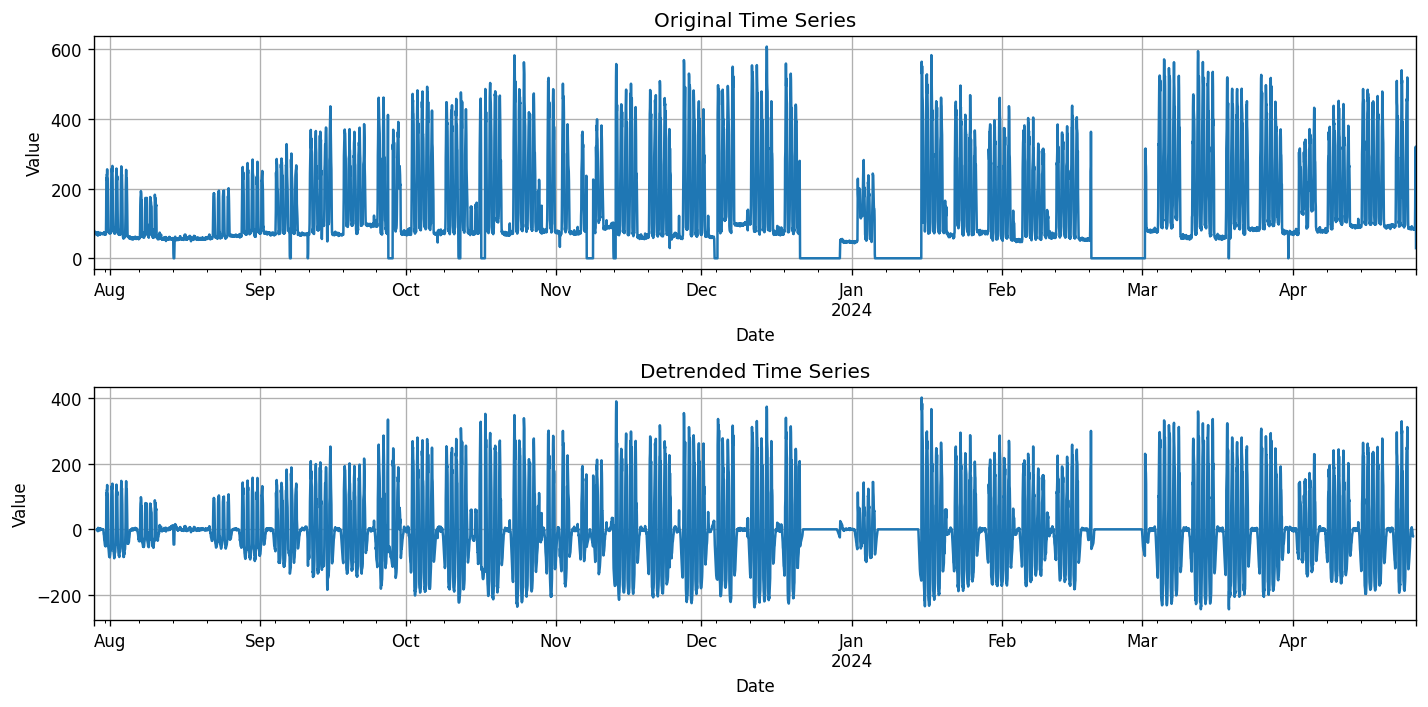

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot the original time series on the first subplot
df["TotW"].plot(ax=axes[0], title="Original Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Value")
axes[0].grid(True)

# Plot the deseasonalized time series on the second subplot
df["detrended"].plot(ax=axes[1], title="Detrended Time Series")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value")

axes[1].grid(True)

plt.tight_layout()

In [17]:
from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(df["detrended"].dropna())
adf_stat = adf_res[0]
adf_pvalue = adf_res[1]

print(f"ADF Statistic: {adf_stat}")
print(f"p-value:       {adf_pvalue}")

ADF Statistic: -21.00569910085896
p-value:       0.0


In [18]:
from statsmodels.tsa.stattools import kpss

kpss_res = kpss(df["TotW"])
kpss_stat = kpss_res[0]
kpss_pvalue = kpss_res[1]

print(f"KPSS Statistic: {kpss_stat}")
print(f"p-value:       {kpss_pvalue}")

KPSS Statistic: 0.48174218030653315
p-value:       0.04577878821924929


## Training


### Grid Search


In [ ]:
data = df["detrended"].fillna(0)
data

datetime
2023-07-28 17:00:00    0.0
2023-07-28 18:00:00    0.0
2023-07-28 19:00:00    0.0
2023-07-28 20:00:00    0.0
2023-07-28 21:00:00    0.0
                      ... 
2024-04-26 06:00:00    0.0
2024-04-26 07:00:00    0.0
2024-04-26 08:00:00    0.0
2024-04-26 09:00:00    0.0
2024-04-26 10:00:00    0.0
Freq: H, Name: detrended, Length: 6546, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# shuffle = False is necessary in timeseries in order to have the train set come before the test set
# source: https://datascience.stackexchange.com/questions/77635/proper-way-to-make-train-test-split-on-time-series
train, test = train_test_split(
    df["TotW"],
    test_size=0.2,
    shuffle=False,
)

In [ ]:
print("Train")
print(f"Start: {train.index[0]}, {train.index[-1]}")
print("Test")
print(f"Start: {test.index[0]}, {test.index[-1]}")

Train
Start: 2023-07-28 17:00:00, 2024-03-02 20:00:00
Test
Start: 2024-03-02 21:00:00, 2024-04-26 10:00:00


In [22]:
# parameters - range each param between 1 and 3
p_params, d_params, q_params = (
    [i for i in range(1, 3)],
    [i for i in range(1, 3)],
    [i for i in range(1, 3)],
)

# temp: fix P, D and Q
P, D, Q = (2, 1, 1)

# hourly data with daily seasonality
m = 24

In [ ]:
import time

# perform grid search - p, d and q are fixed, and P, D and Q are rotating
results = []
for p in p_params:
    for d in d_params:
        for q in q_params:
            time_start = time.time()
            seasonal_order = (P, D, Q, m)
            order = (p, d, q)

            print(f"Starting training {order}, {seasonal_order}")

            # ARIMA
            model = ARIMA(
                train,
                order=order,
                seasonal_order=seasonal_order,
            ).fit()

            # make predictions on test set (i.e. the period after the last training data's timestamp)
            pred = model.predict(len(train), len(train) + len(test) - 1)

            score = mean_absolute_error(test, pred)  # type: ignore
            exec_time = time.time() - time_start

            results.append(
                {
                    "p": p,
                    "d": d,
                    "q": q,
                    "P": P,
                    "D": D,
                    "Q": Q,
                    "score": score,
                    "exec_time": exec_time,
                }
            )

            plt.plot(test, label="Test")  # type: ignore
            plt.plot(pred, label="Prediction")
            plt.legend()
            plt.title(
                f"Order: {order}, Seasonal order: {seasonal_order}, MAE: {results[-1]["score"]}, Time: {exec_time}"
            )

            plt.tight_layout()
            plt.show()

In [ ]:
results

### KFold - ARIMA


In [24]:
data = df["TotW"]

X = pd.Series(data.index)
y = pd.Series(data.values)

In [25]:
from sklearn.model_selection import TimeSeriesSplit

n_splits = 10
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=120,
)

Split 1/10
Split 2/10


KeyboardInterrupt: 

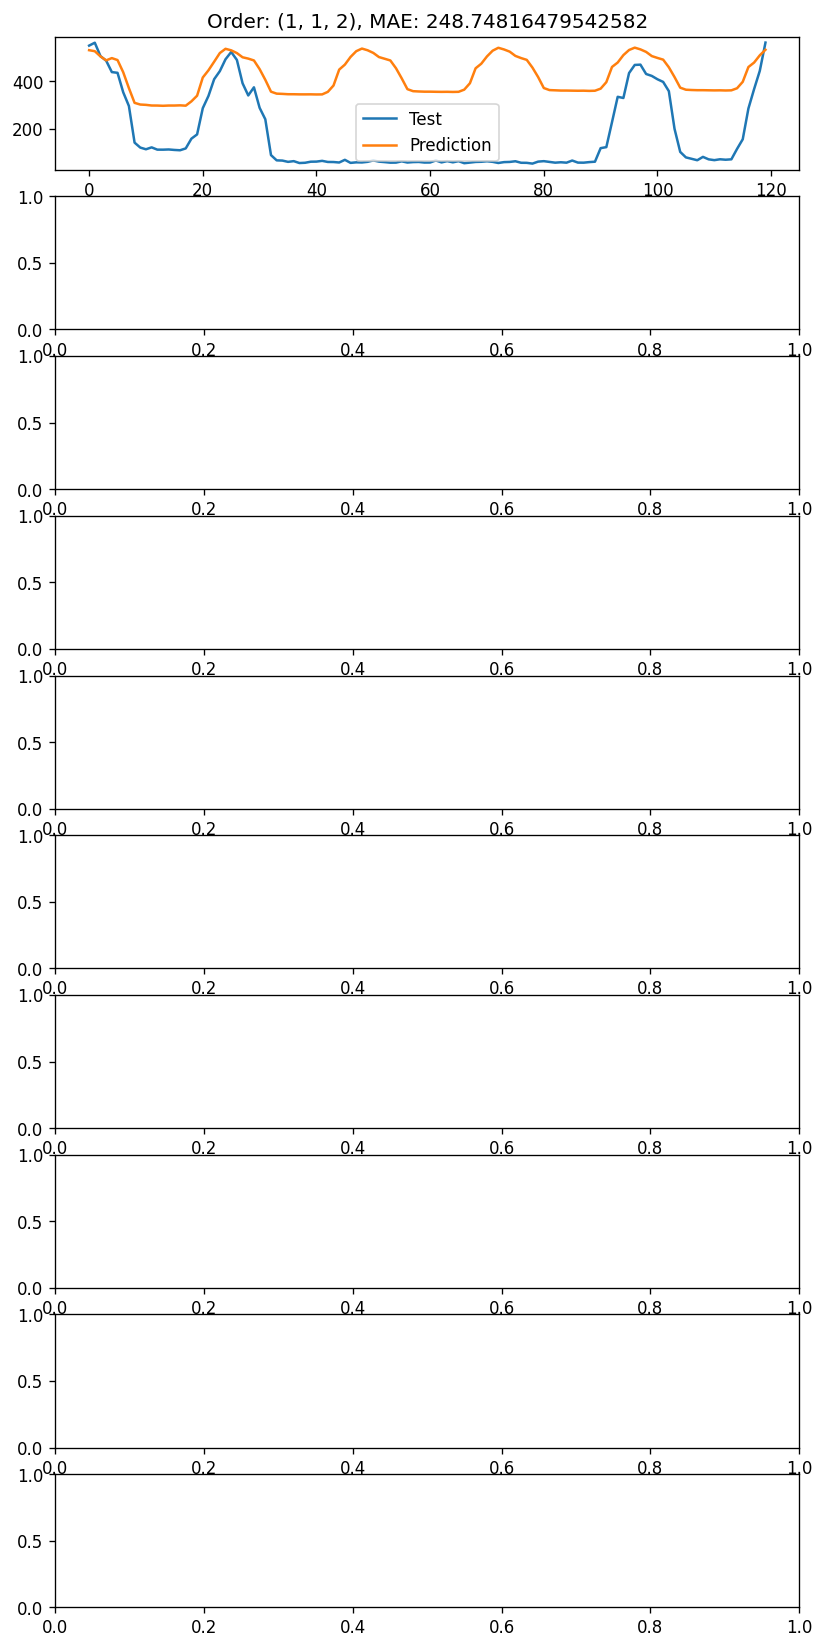

In [27]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

fig, ax = plt.subplots(n_splits, 1, figsize=(8, 17))

scores, params = [], []
for i, (train_index, test_index) in enumerate(tscv.split(df)):
    print(f"Split {i + 1}/{n_splits}")
    # Get the training and testing sets
    train_data = df["TotW"].iloc[train_index].values
    test_data = df["TotW"].iloc[test_index].values

    # ARIMA
    order = (1, 1, 2)
    model = ARIMA(
        train_data,
        order=order,
        seasonal_order=(2, 1, 2, 24),  # 24 = hourly data with daily seasonality
    ).fit()

    # make predictions on test set (i.e. the period after the last training data's timestamp)
    pred = model.predict(len(train_data), len(train_data) + len(test_data) - 1)

    # calculate the MAE for split
    scores.append(mean_absolute_error(test_data, pred))  # type: ignore
    params.append(order)

    ax[i].plot(test_data, label="Test")
    ax[i].plot(pred, label="Prediction")
    ax[i].legend()
    ax[i].set_title(f"Order: {order}, MAE: {scores[-1]}")


# output the MAE for each split and the average MAE
print("Mean Absolute Error for each split:", scores)
print("Average MAE:", np.mean(scores))

plt.tight_layout()

In [ ]:
print(f"Sum of scores: {sum(scores)}")
print(f"Avg of scores: {sum(scores)/len(scores)}")
print(f"Min of scores: {min(scores)}")
print(f"Max of scores: {max(scores)}")

### KFold - AutoARIMA


In [ ]:
data = df["TotW"]

X = pd.Series(data.index)
y = pd.Series(data.values)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

n_splits = 10
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=120,
)

Split 1/10
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=52388.751, Time=33.08 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=67421.879, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=53313.087, Time=6.32 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=59828.668, Time=10.65 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=71085.856, Time=0.04 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=52911.252, Time=19.55 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=52712.324, Time=24.65 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=inf, Time=93.28 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=inf, Time=108.91 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=53422.726, Time=2.09 sec


KeyboardInterrupt: 

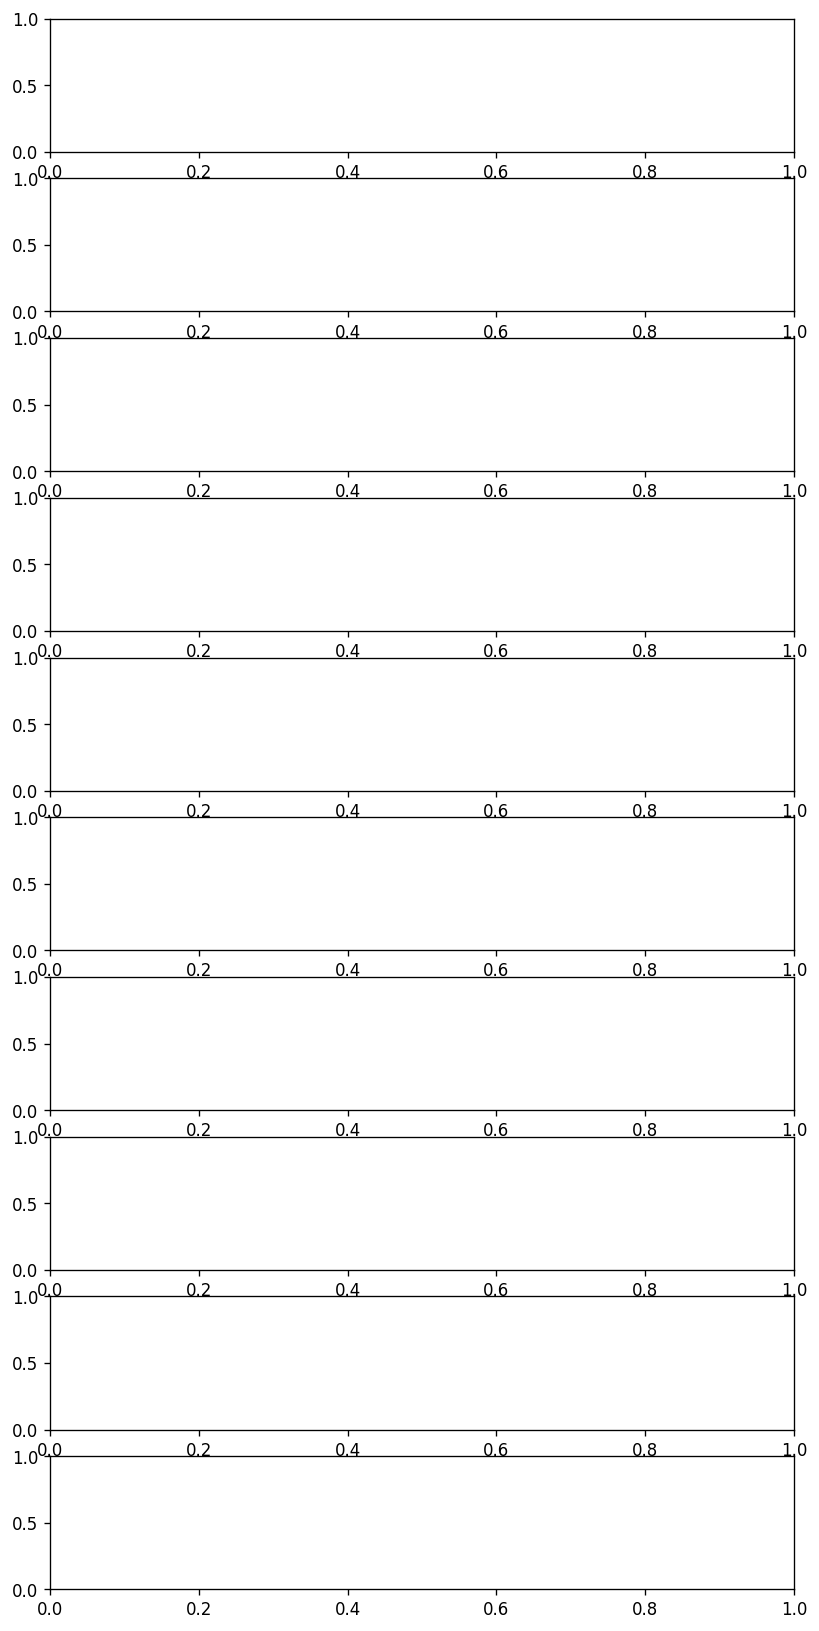

In [ ]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

fig, ax = plt.subplots(n_splits, 1, figsize=(8, 17))

scores, params = [], []
for i, (train_index, test_index) in enumerate(tscv.split(df)):
    print(f"Split {i + 1}/{n_splits}")
    # Get the training and testing sets
    train_data = df["TotW"].iloc[train_index].values
    test_data = df["TotW"].iloc[test_index].values

    # Auto-ARIMA
    model = auto_arima(
        train_data,
        test="adf",
        max_p=2,
        max_d=2,
        max_q=2,
        m=24,
        trace=True,
        seasonal=True,
        stepwise=True,  # Use stepwise algorithm to find optimal parameters
        suppress_warnings=True,
    )

    order = model.order

    # make predictions on test set (i.e. the period after the last training data's timestamp)
    pred = model.predict(len(test_data))

    # calculate the MAE for split
    scores.append(mean_absolute_error(test_data, pred))  # type: ignore
    params.append(order)

    ax[i].plot(test_data, label="Test")
    ax[i].plot(pred, label="Prediction")
    ax[i].legend()
    ax[i].set_title(f"Order: {order}, MAE: {scores[-1]}")


# output the MAE for each split and the average MAE
print("Mean Absolute Error for each split:", scores)
print("Average MAE:", np.mean(scores))

plt.tight_layout()

In [ ]:
print(f"Sum of scores: {sum(scores)}")
print(f"Avg of scores: {sum(scores)/len(scores)}")
print(f"Min of scores: {min(scores)}")
print(f"Max of scores: {max(scores)}")